# First notebook Cells

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 


### Load Data

In [2]:
df = pd.read_csv('../data/raw/mock_member_data.csv')

### Preview

In [3]:
df.head() # Preview the first few rows of the dataset
# Each row represents one synthetic health plan member.

,member_id,age,gender,region,plan_type,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,prior_awv_rate,ed_visits,ip_admits,monthly_cost,awv_completed
0,M00001,69,Male,Suburban,Medicare Advantage,40.7,2,68.9,1,1,0.333333,2,0,3920.62,1
1,M00002,32,Female,Urban,DSNP,80.0,3,30.4,0,0,0.000000,2,0,2446.74,0
2,M00003,89,Female,Suburban,Medicare Advantage,49.6,3,86.3,1,3,1.000000,0,0,1419.49,1
3,M00004,78,Male,Suburban,Medicare Advantage,45.7,4,63.1,1,1,0.333333,2,1,3703.93,1
4,M00005,38,Male,Suburban,Medicare Advantage,32.4,0,55.6,0,0,0.000000,0,0,471.10,1


### Shape

In [4]:
df.shape # Check the number of rows and columns in the dataset

(3000, 15)

### Columns

In [5]:
df.columns.tolist() # List all the column names in the dataset to understand the features available

['member_id',
 'age',
 'gender',
 'region',
 'plan_type',
 'sdoh_risk_score',
 'chronic_condition_count',
 'engagement_score',
 'pcp_attributed_24mo',
 'prior_awv_count',
 'prior_awv_rate',
 'ed_visits',
 'ip_admits',
 'monthly_cost',
 'awv_completed']

### Data Dictionary

1. awv_completed : Binary target for wheter member completed Annual Wellness Visit.
2. monthly_cost : Simulated monhtly healthcare cost
3. ed_visits : Emergency department visit count
4. ip_admits : Inpatient admission count

# Structural Checks

### Data Types

In [6]:
df.info() # Get a concise summary of the DataFrame, including data types and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   member_id                3000 non-null   str    
 1   age                      3000 non-null   int64  
 2   gender                   3000 non-null   str    
 3   region                   3000 non-null   str    
 4   plan_type                3000 non-null   str    
 5   sdoh_risk_score          3000 non-null   float64
 6   chronic_condition_count  3000 non-null   int64  
 7   engagement_score         3000 non-null   float64
 8   pcp_attributed_24mo      3000 non-null   int64  
 9   prior_awv_count          3000 non-null   int64  
 10  prior_awv_rate           3000 non-null   float64
 11  ed_visits                3000 non-null   int64  
 12  ip_admits                3000 non-null   int64  
 13  monthly_cost             3000 non-null   float64
 14  awv_completed            3000 non-n

### Summary Stats

In [7]:
df.describe() # Get summary statistics for numerical columns to understand the distribution of the data

,age,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,prior_awv_rate,ed_visits,ip_admits,monthly_cost,awv_completed
count,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,52.891000,58.367467,2.36600,44.557533,0.498333,0.973667,0.324556,1.167000,0.447000,2176.503653,0.519333
std,20.684448,15.216893,1.49559,14.583777,0.500081,0.997984,0.332661,1.157104,0.684602,1277.483939,0.499709
min,18.000000,2.400000,0.00000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000
25%,35.000000,47.675000,1.00000,34.700000,0.000000,0.000000,0.000000,0.000000,0.000000,1213.017500,0.000000
50%,52.000000,58.800000,2.00000,44.500000,0.000000,1.000000,0.333333,1.000000,0.000000,1934.470000,1.000000
75%,71.000000,69.300000,3.00000,54.600000,1.000000,2.000000,0.666667,2.000000,1.000000,2861.802500,1.000000
max,89.000000,100.000000,8.00000,90.300000,1.000000,3.000000,1.000000,7.000000,4.000000,8734.220000,1.000000


### Missing Values 

In [8]:
df.isnull().sum() # Check for missing values in each column

member_id                  0
age                        0
gender                     0
region                     0
plan_type                  0
sdoh_risk_score            0
chronic_condition_count    0
engagement_score           0
pcp_attributed_24mo        0
prior_awv_count            0
prior_awv_rate             0
ed_visits                  0
ip_admits                  0
monthly_cost               0
awv_completed              0
dtype: int64

### Duplicate member IDs

In [9]:
df["member_id"].duplicated().sum() # Check for duplicate member IDs to ensure data integrity

np.int64(0)

# Categorical review

In [10]:
df["gender"].value_counts() # Check gender distribution   

gender
Female    1654
Male      1346
Name: count, dtype: int64

In [11]:
df["region"].value_counts() # Check region distribution       

region
Urban       1482
Suburban     902
Rural        616
Name: count, dtype: int64

In [12]:
df["plan_type"].value_counts() # Check plan_type mix    

plan_type
Medicaid              1513
Medicare Advantage    1079
DSNP                   408
Name: count, dtype: int64

In [13]:
df["awv_completed"].value_counts() # Check AWV target balance    

awv_completed
1    1558
0    1442
Name: count, dtype: int64

# Numerical Distribution Review


In [14]:
numeric_cols = [
    "age",
    "sdoh_risk_score",
    "chronic_condition_count",
    "engagement_score",
    "pcp_attributed_24mo",
    "prior_awv_count",
    "prior_awv_rate",
    "ed_visits",
    "ip_admits",
    "monthly_cost",
    "awv_completed"
]

df[numeric_cols].describe()

# Note that awv_completed is binary, not truly continuous numeric. For example, awv_completed.mean() shouold be its completion rate.

,age,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,prior_awv_rate,ed_visits,ip_admits,monthly_cost,awv_completed
count,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,52.891000,58.367467,2.36600,44.557533,0.498333,0.973667,0.324556,1.167000,0.447000,2176.503653,0.519333
std,20.684448,15.216893,1.49559,14.583777,0.500081,0.997984,0.332661,1.157104,0.684602,1277.483939,0.499709
min,18.000000,2.400000,0.00000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000
25%,35.000000,47.675000,1.00000,34.700000,0.000000,0.000000,0.000000,0.000000,0.000000,1213.017500,0.000000
50%,52.000000,58.800000,2.00000,44.500000,0.000000,1.000000,0.333333,1.000000,0.000000,1934.470000,1.000000
75%,71.000000,69.300000,3.00000,54.600000,1.000000,2.000000,0.666667,2.000000,1.000000,2861.802500,1.000000
max,89.000000,100.000000,8.00000,90.300000,1.000000,3.000000,1.000000,7.000000,4.000000,8734.220000,1.000000


In [15]:
df[numeric_cols].min() # Check the minimum values for numeric columns to identify any potential data entry errors (e.g., negative values)

age                        18.0
sdoh_risk_score             2.4
chronic_condition_count     0.0
engagement_score            5.0
pcp_attributed_24mo         0.0
prior_awv_count             0.0
prior_awv_rate              0.0
ed_visits                   0.0
ip_admits                   0.0
monthly_cost               50.0
awv_completed               0.0
dtype: float64

In [16]:
df[numeric_cols].max() # Check the maximum values for numeric columns to identify any potential outliers or data entry errors (e.g., extremely high values)


age                          89.00
sdoh_risk_score             100.00
chronic_condition_count       8.00
engagement_score             90.30
pcp_attributed_24mo           1.00
prior_awv_count               3.00
prior_awv_rate                1.00
ed_visits                     7.00
ip_admits                     4.00
monthly_cost               8734.22
awv_completed                 1.00
dtype: float64

# Create First Charts

### Age Distribution

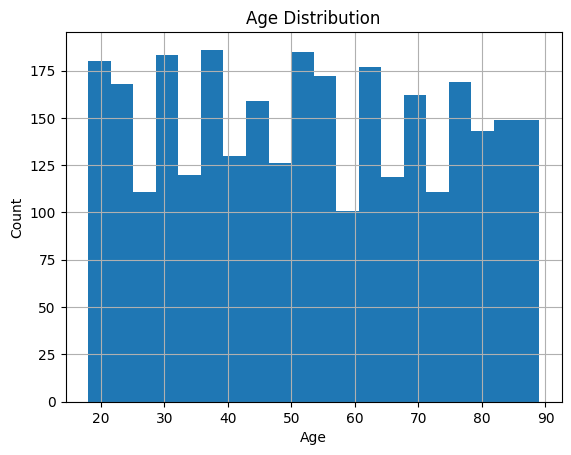

In [17]:
df["age"].hist(bins=20) # Visualize the distribution of the "age" column to identify any skewness or outliers
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

### Monthly Cost Distribution

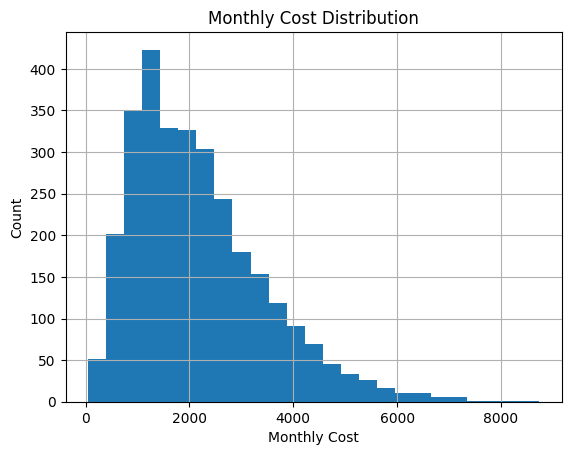

In [18]:
df["monthly_cost"].hist(bins=25) # Visualize the distribution of the "monthly_cost" column to identify any skewness or outliers
plt.title("Monthly Cost Distribution")
plt.xlabel("Monthly Cost")
plt.ylabel("Count")
plt.show()

### Plan Type Counts

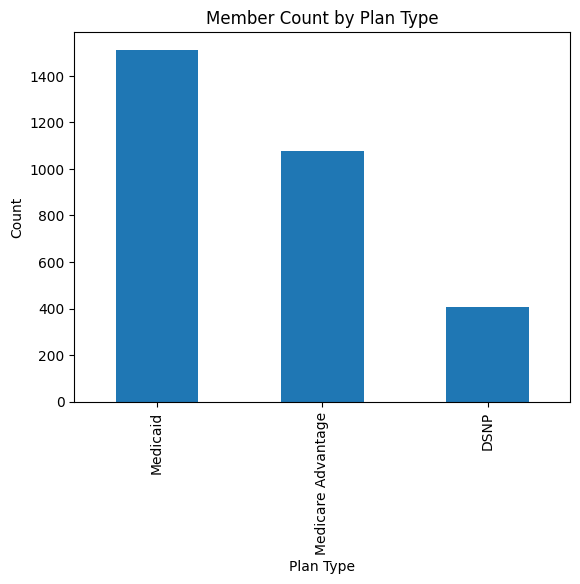

In [19]:
df["plan_type"].value_counts().plot(kind="bar")
plt.title("Member Count by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Count")
plt.show()

### AWV completion counts

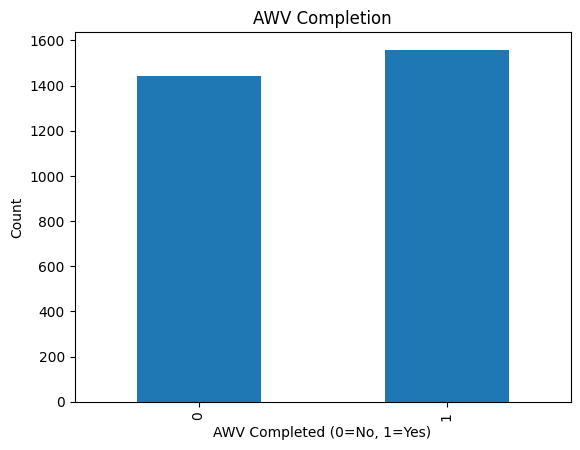

In [20]:
df["awv_completed"].value_counts().sort_index().plot(kind="bar")
plt.title("AWV Completion")
plt.xlabel("AWV Completed (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

### Chronic Condition Count Distribution

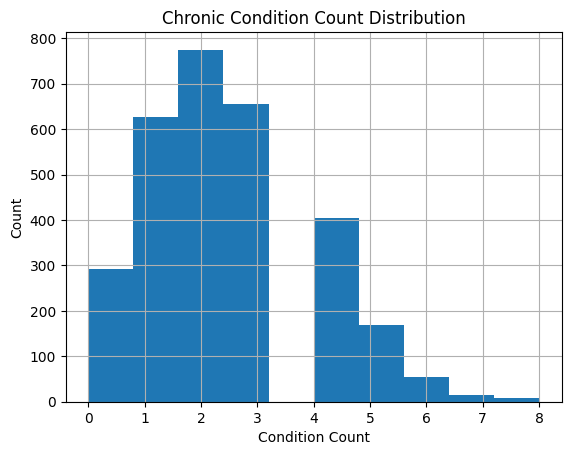

In [21]:
df["chronic_condition_count"].hist(bins=10)
plt.title("Chronic Condition Count Distribution")
plt.xlabel("Condition Count")
plt.ylabel("Count")
plt.show()

# Grouped EDA

### Average Monthly Cost By Plan Type

In [22]:
df.groupby("plan_type")[["sdoh_risk_score", "ed_visits", "ip_admits", "monthly_cost"]].mean() # check whether plan type behaves differently 

,sdoh_risk_score,ed_visits,ip_admits,monthly_cost
plan_type,,,,
DSNP,66.312255,1.340686,0.487745,2711.696593
Medicaid,61.065169,1.208857,0.440846,2052.472961
Medicare Advantage,51.580538,1.042632,0.440222,2148.051121


### Average SDOH Risk, Engagement, ED Visits By Region

In [23]:
df.groupby("region")[["sdoh_risk_score", "engagement_score", "ed_visits"]].mean() # Check whether region affects SDOH, engagement, and ED use

,sdoh_risk_score,engagement_score,ed_visits
region,,,
Rural,66.514286,33.108279,1.339286
Suburban,46.805211,53.874169,0.957871
Urban,62.018421,43.646019,1.222672


### Average Ed Visits IP Admits AWV Completed Monthly Cost By Attributed Status

In [24]:
df.groupby("pcp_attributed_24mo")[["ed_visits", "ip_admits", "awv_completed", "monthly_cost"]].mean() # Check PCP attribution relationship with utilization and AWV

,ed_visits,ip_admits,awv_completed,monthly_cost
pcp_attributed_24mo,,,,
0,1.283056,0.510299,0.399336,2314.777355
1,1.050167,0.383278,0.640134,2037.305043


### Average ED Visits By Chronic Condition Count

In [25]:
df.groupby("chronic_condition_count").agg(
    member_count = ("member_id", "count"),
    avg_ed_visits = ("ed_visits", "mean")
    )

,member_count,avg_ed_visits
chronic_condition_count,,
0,292,0.654110
1,627,0.848485
2,775,1.058065
3,656,1.367378
4,405,1.476543
5,168,1.815476
6,54,1.814815
7,15,2.800000
8,8,2.250000


### AWV Completion Rate By Plan Type

In [26]:
df.groupby("plan_type")["awv_completed"].mean().sort_values()

plan_type
DSNP                  0.428922
Medicaid              0.516854
Medicare Advantage    0.556997
Name: awv_completed, dtype: float64

### AWV Completion Rate By Engagement Quartile

In [27]:
df['engagement_group'] = pd.qcut(
    df["engagement_score"],
    q=4,
    labels = ["Q1", "Q2", "Q3", "Q4"]
)

engagement_awv_summary = df.groupby("engagement_group", observed=True).agg(
    avg_engagement_score=("engagement_score", "mean"),  # Average engagement score in each quartile
    awv_completion_rate=("awv_completed", "mean"),  # AWV completion rate in each quartile
    member_count=("member_id", "count")  # Number of members in each quartile
)

engagement_awv_summary  # Display engagement and AWV relationship

,avg_engagement_score,awv_completion_rate,member_count
engagement_group,,,
Q1,25.949139,0.268874,755
Q2,39.830563,0.465147,746
Q3,49.432759,0.586207,754
Q4,63.214899,0.759732,745


### Average Monthly Cost By AWV Completion

In [28]:
df.groupby("awv_completed")["monthly_cost"].mean()

awv_completed
0    2288.126040
1    2073.192047
Name: monthly_cost, dtype: float64

# Create Age Bands

In [29]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 34, 49, 64, 79, 100],
    labels=["18-34", "35-49", "50-64", "65-79", "80+"]
)

In [30]:
df["age_group"].value_counts().sort_index()

age_group
18-34    730
35-49    633
50-64    635
65-79    614
80+      388
Name: count, dtype: int64

In [31]:
df.groupby("age_group", observed = True)["monthly_cost"].mean()

age_group
18-34    1594.246247
35-49    1662.838452
50-64    2114.688567
65-79    2943.931433
80+      2996.735361
Name: monthly_cost, dtype: float64

In [32]:
df.groupby("age_group", observed = True)["awv_completed"].mean()

age_group
18-34    0.482192
35-49    0.500790
50-64    0.533858
65-79    0.540717
80+      0.561856
Name: awv_completed, dtype: float64

# Relationship Checks

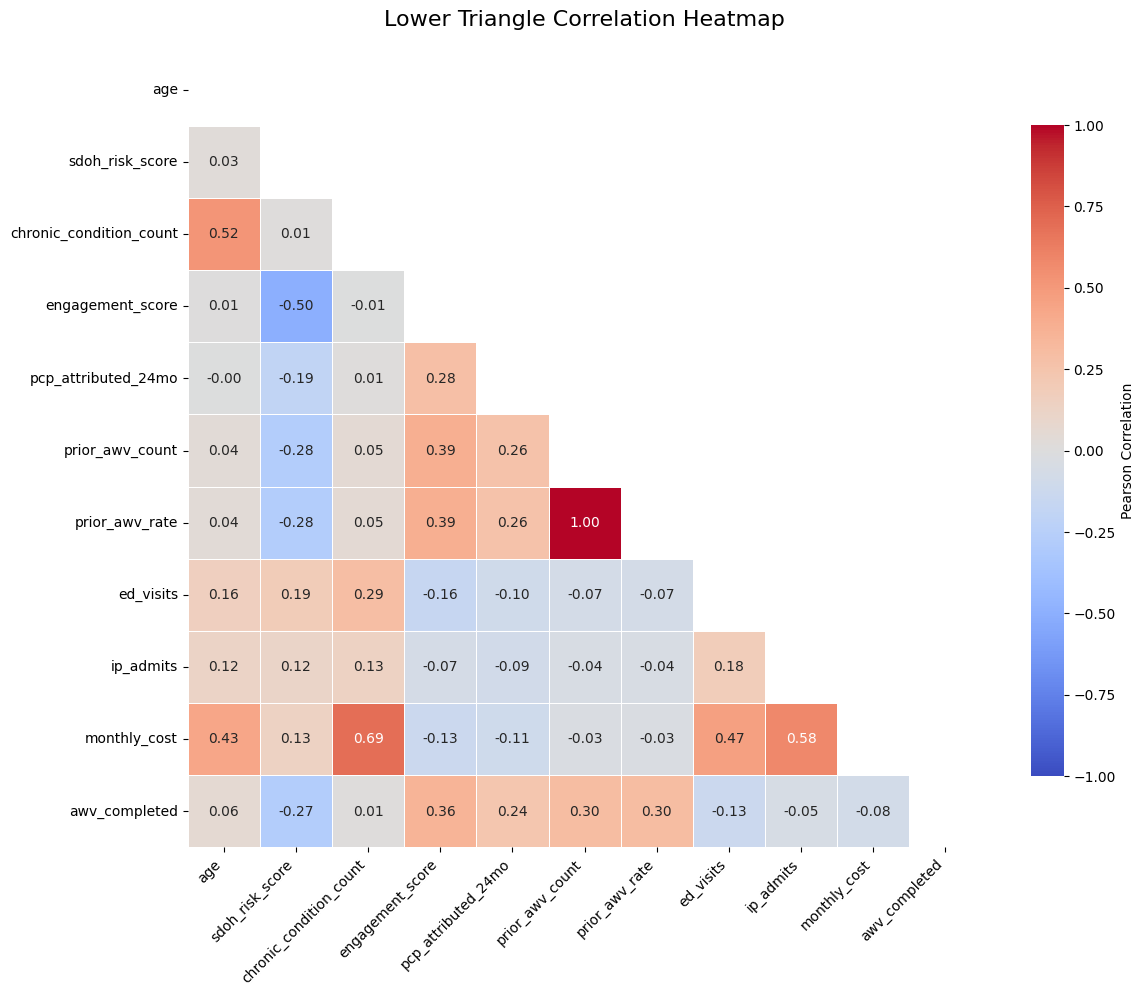

In [33]:
corr_cols = [
    "age",  # Member age
    "sdoh_risk_score",  # Social risk score
    "chronic_condition_count",  # Disease burden
    "engagement_score",  # Engagement level
    "pcp_attributed_24mo",  # PCP attribution flag
    "prior_awv_count",  # Prior AWV completion count
    "prior_awv_rate",  # Normalized prior AWV history
    "ed_visits",  # ED utilization
    "ip_admits",  # Inpatient utilization
    "monthly_cost",  # Potential regression outcome
    "awv_completed"  # Potential classification outcome
]

corr_matrix = df[corr_cols].corr()  # Review pairwise correlations among numeric variables

# np.triu returns the upper triangle of an array. We use ones_like to create a boolean mask.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Set up the matplotlib figure size
plt.figure(figsize=(12, 10))

# 4. Create the heatmap with the mask applied
sns.heatmap(
    corr_matrix, 
    mask=mask,             # Apply the upper triangle mask
    annot=True,            # Show values
    cmap="coolwarm",       # Diverging colormap
    fmt=".2f",             # 2 decimal places
    vmin=-1, vmax=1,       # Scale boundary
    square=True,           # Square cells
    linewidths=0.5,        # Grid lines
    cbar_kws={"shrink": .8, "label": "Pearson Correlation"} 
)

# 5. Add formatting
plt.title("Lower Triangle Correlation Heatmap", fontsize=16, pad=20)

# Rotate x-axis labels to prevent overlap
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

The heatmap shows pairwise Pearson correlations among selected numeric variables. This is used as a quick EDA tool to identify linear relationships between demographics, risk, utilization, cost, engagement, PCP attribution, and AWV completion.

Because this is exploratory analysis, these correlations should be interpreted as associations only, not causal effects.

# Write Down Findings

## Initial Findings

1. Monthly cost appears to increase with chronic condition count, inpatient admissions, and age.
2. Engagement score shows a positive relationship with AWV completion in grouped analysis, with completion rates increasing from 26.9% in the lowest quartile to 76.0% in the highest quartile.
3. The AWV target is relatively balanced, with slightly more completed than non-completed members. Since ED visits and inpatient admits are major cost drivers, it may be useful to examine whether AWV completion is associated with lower utilization.
4. Higher engagement scores may be associated with lower cost and lower utilization, but this should not be interpreted as a causal relationship without further analysis.
5. Average monthly cost is higher among AWV non-compliant members than compliant members. This may reflect differences in age, disease burden, or other confounding factors rather than the direct effect of AWV completion itself.

### Export EDA-Enhanced Dataset

The exported dataset includes EDA-created fields such as `engagement_group` and `age_group`. These features are useful for analysis, but future modeling notebooks should avoid preprocessing leakage by creating train/test splits before fitting any data-driven transformations.

In [34]:
df.to_csv("../data/processed/member_eda_ready.csv", index = False)